# LINDA VASQUEZ Proyecto final 4Geeks 2.0

## >>> Requisito de carga y SQL

In [1]:
# Importacion de librerias
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from xgboost import XGBClassifier, XGBRegressor
import joblib

warnings.filterwarnings('ignore') # para que no me imprima tanto filterwarning

# Como buena practica se cargan las credenciales del entorno
load_dotenv()
url_base_datos = os.getenv('DATABASE_URL')

# Filtro a 25 variables que me interesan
columnas_elegidas = [
    'TARGET', 'AMT_CREDIT', 
    'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE', 'DAYS_LAST_PHONE_CHANGE',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'REGION_RATING_CLIENT', 'NAME_CONTRACT_TYPE'
]

# Carga (ligera para no matar a mi equipo) y muestreo
ruta_archivo = '../data/raw/application_train.csv'
datos_crudos = pd.read_csv(ruta_archivo, usecols=columnas_elegidas)

# Muestra aleatoria robusta de 75,000 filas
datos_muestra = datos_crudos.sample(n=75000, random_state=42)

# Inyeccion a PostgreSQL
motor_bd = create_engine(url_base_datos)
datos_muestra.to_sql('creditos_riesgo', motor_bd, if_exists='replace', index=False)

# Extracción con SQL
consulta_sql = """
    SELECT * FROM creditos_riesgo;
"""
datos_sql = pd.read_sql(consulta_sql, motor_bd)

# Checo si funciona
print(f"Datos extraidos vía SQL: {datos_sql.shape}")
datos_sql.head()

Datos extraidos vía SQL: (75000, 25)


,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DEF_30_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_YEAR
0,0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,418500.0,...,-762,Sales staff,4.0,2,0.675878,0.604894,0.000527,0.0,-2.0,1.0
1,0,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,1179000.0,...,-1141,Managers,1.0,3,0.430827,0.425351,0.712155,0.0,-1071.0,3.0
2,0,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,495000.0,...,-639,Sales staff,2.0,2,0.527239,0.531760,0.207964,0.0,-1435.0,3.0
3,0,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,225000.0,...,-6982,High skill tech staff,1.0,1,NaN,0.693521,0.614414,0.0,-2000.0,0.0
4,0,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,234000.0,...,-1105,Laborers,1.0,2,0.654882,0.560690,0.636376,0.0,-173.0,4.0


## >>> Análisis descriptivo

In [2]:
# para las variables numéricas: medias, desviaciones y cuartiles :D
print("1) Analisis Numerico (Medias, Desviaciones y Cuartiles):")
resumen_num = datos_sql.describe().T
display(resumen_num)

# para las variables categóricas : modas y frecuencias
print(" Analisis Categorico (Modas y valores unicos):")
resumen_cat = datos_sql.describe(include=['object']).T
display(resumen_cat)

# analisis de distribución teórica (Asimetría y Curtosis)
# se filtran solo las columnas numéricas para evitar errores
columnas_numericas = datos_sql.select_dtypes(include=['float64', 'int64'])

distribucion_teorica = pd.DataFrame({
    'Asimetria_Sesgo': columnas_numericas.skew(),
    'Curtosis_Colas': columnas_numericas.kurtosis()
})

print("Análisis de Distribución Teórica:")
display(distribucion_teorica)

1) Analisis Numerico (Medias, Desviaciones y Cuartiles):


,count,mean,std,min,25%,50%,75%,max
TARGET,75000.0,0.080440,0.271975,0.000000,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,75000.0,0.418853,0.726917,0.000000,0.000000,0.000000,1.000000,1.400000e+01
AMT_INCOME_TOTAL,75000.0,169850.218693,443249.893158,25650.000000,112500.000000,148500.000000,202500.000000,1.170000e+08
AMT_CREDIT,75000.0,597117.765420,400972.012401,45000.000000,270000.000000,511920.000000,808650.000000,4.050000e+06
AMT_ANNUITY,74997.0,27073.165007,14441.808200,1980.000000,16573.500000,24898.500000,34465.500000,2.301615e+05
AMT_GOODS_PRICE,74937.0,536623.958245,367983.852731,45000.000000,238500.000000,450000.000000,679500.000000,4.050000e+06
DAYS_BIRTH,75000.0,-16042.151800,4372.707773,-25201.000000,-19685.000000,-15750.000000,-12411.000000,-7.673000e+03
DAYS_EMPLOYED,75000.0,63874.000267,141329.343479,-17522.000000,-2767.000000,-1214.000000,-290.750000,3.652430e+05
CNT_FAM_MEMBERS,74999.0,2.152069,0.916430,1.000000,2.000000,2.000000,3.000000,1.600000e+01
REGION_RATING_CLIENT,75000.0,2.051547,0.507819,1.000000,2.000000,2.000000,2.000000,3.000000e+00


 Analisis Categorico (Modas y valores unicos):


,count,unique,top,freq
NAME_CONTRACT_TYPE,75000,2,Cash loans,67927
CODE_GENDER,75000,3,F,49551
FLAG_OWN_CAR,75000,2,N,49673
FLAG_OWN_REALTY,75000,2,Y,51873
NAME_INCOME_TYPE,75000,8,Working,38807
NAME_EDUCATION_TYPE,75000,5,Secondary / secondary special,53431
NAME_FAMILY_STATUS,75000,6,Married,47717
NAME_HOUSING_TYPE,75000,6,House / apartment,66469
OCCUPATION_TYPE,51454,18,Laborers,13435


Análisis de Distribución Teórica:


,Asimetria_Sesgo,Curtosis_Colas
TARGET,3.085366,7.519684
CNT_CHILDREN,1.962544,6.503951
AMT_INCOME_TOTAL,245.128640,64391.083895
AMT_CREDIT,1.257678,2.051597
AMT_ANNUITY,1.591954,8.008693
AMT_GOODS_PRICE,1.367258,2.526831
DAYS_BIRTH,-0.118376,-1.050170
DAYS_EMPLOYED,1.662891,0.766780
CNT_FAM_MEMBERS,0.998909,2.530662
REGION_RATING_CLIENT,0.088061,0.820237


## >>> Limpieza de datos, ajustes despues del analisis descriptivo y division train - test

In [3]:
# Copia de los datos crudos para empezar a limpiar
datos_limpios = datos_sql.copy()

# Aquí ajusto cosas que encontre en el analisis descriptivo:

# 365,243 dias laborados es un valor irreal
# remplazo el valor de 365243 por nulo (np.nan)
datos_limpios['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# La edad de los clientes esta expresada en negativo
# Uso la funcion abs() para quitar el negativo y se divide entre 365 para pasarlo a años de edad
datos_limpios['EDAD_ANOS'] = abs(datos_limpios['DAYS_BIRTH']) / 365
datos_limpios['ANTIGUEDAD_ANOS'] = abs(datos_limpios['DAYS_EMPLOYED']) / 365
datos_limpios['DIAS_CAMBIO_TEL'] = abs(datos_limpios['DAYS_LAST_PHONE_CHANGE'])

# Se eliminan las columnas viejas en días porque ya cree las nuevas corregidas
datos_limpios.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_LAST_PHONE_CHANGE'], axis=1, inplace=True)

# aunque la muestra es de 75,000 registros hay variables que tienen nulos
# para los números se rellena con el valor de la mediana para ir a la segura
columnas_num = datos_limpios.select_dtypes(include=['float64', 'int64']).columns
for col in columnas_num:
    datos_limpios[col].fillna(datos_limpios[col].median(), inplace=True)

# para los textos vacios se rellena con la categoría "Desconocido"
columnas_cat = datos_limpios.select_dtypes(include=['object']).columns
for col in columnas_cat:
    datos_limpios[col].fillna('Desconocido', inplace=True)

# conversion de texto a numero, variables categoricas a columnas de 0 y 1
datos_procesados = pd.get_dummies(datos_limpios, columns=columnas_cat, drop_first=True)

# division de datos train y test
X = datos_procesados.drop(['TARGET'], axis=1) # Las variables predictoras
y = datos_procesados['TARGET']                # Predecir si es moroso o no

# stratify=y para obligar a que tanto en el set de entreno como de prueba quede la misma proporcion de morosos
X_entreno, X_prueba, y_entreno, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Guardado de datos limpios
X_entreno.to_csv('../data/processed/X_entreno.csv', index=False)
X_prueba.to_csv('../data/processed/X_prueba.csv', index=False)
y_entreno.to_csv('../data/processed/y_entreno.csv', index=False)
y_prueba.to_csv('../data/processed/y_prueba.csv', index=False)

print(f"Datos guardados. NOTA: las 25 columnas se expandieron a {X_entreno.shape[1]} por pasar las variables categoricas a columnas de 0 y 1")

Datos guardados. NOTA: las 25 columnas se expandieron a 58 por pasar las variables categoricas a columnas de 0 y 1


## >>> EDA tradicional

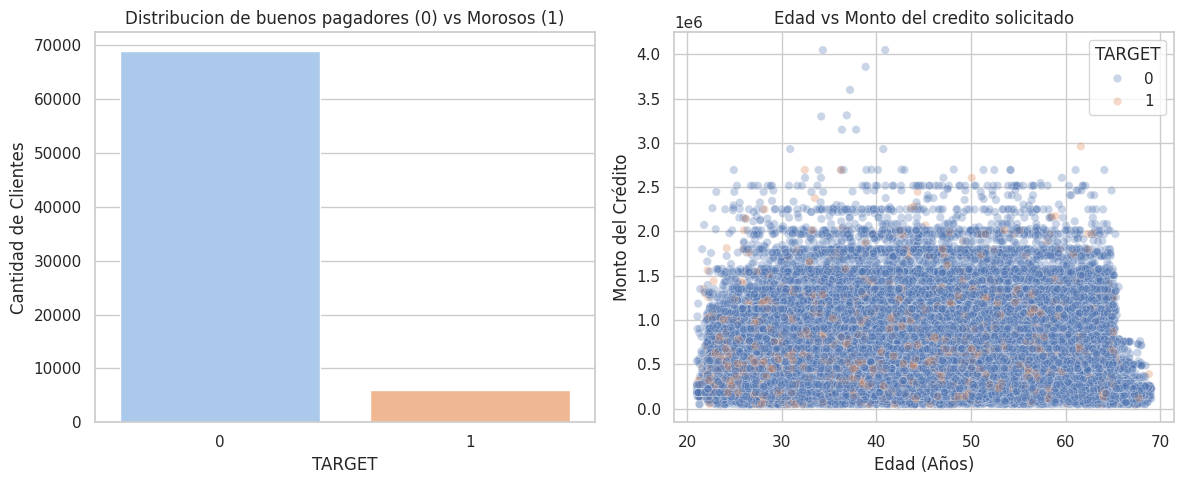

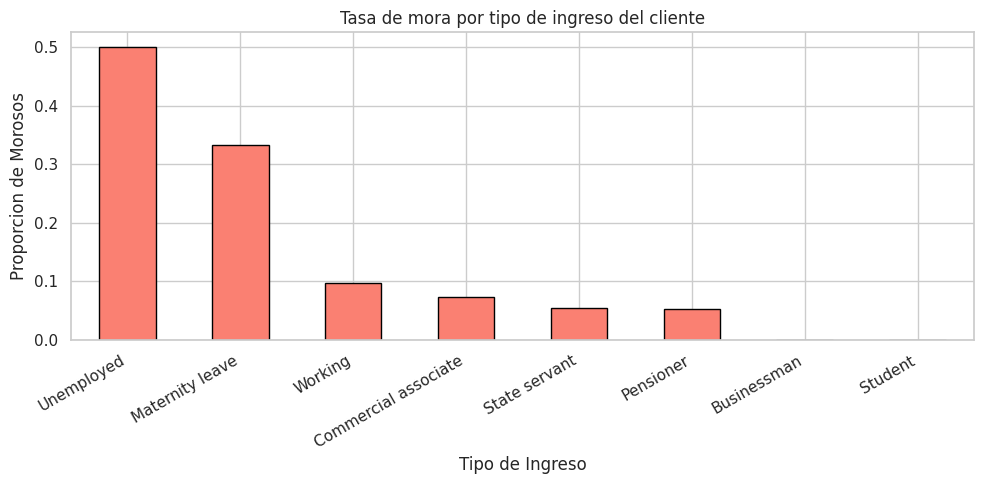

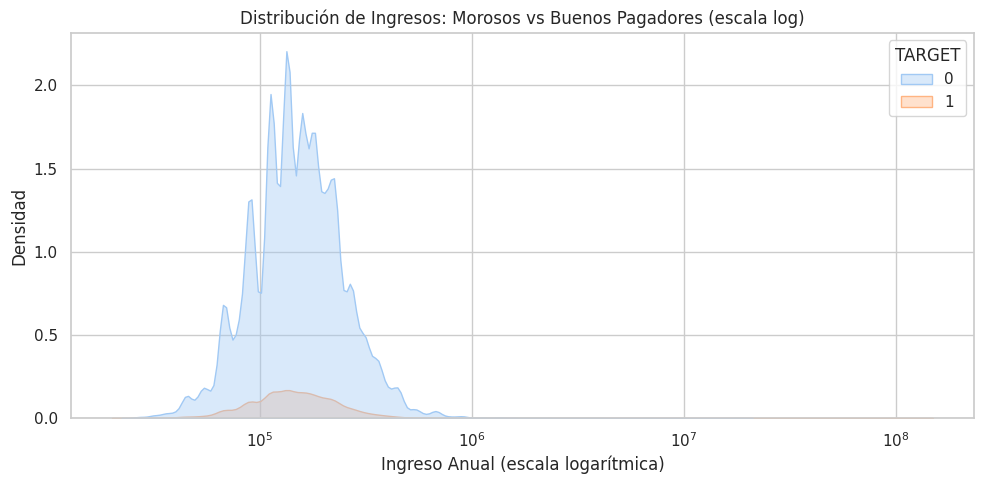

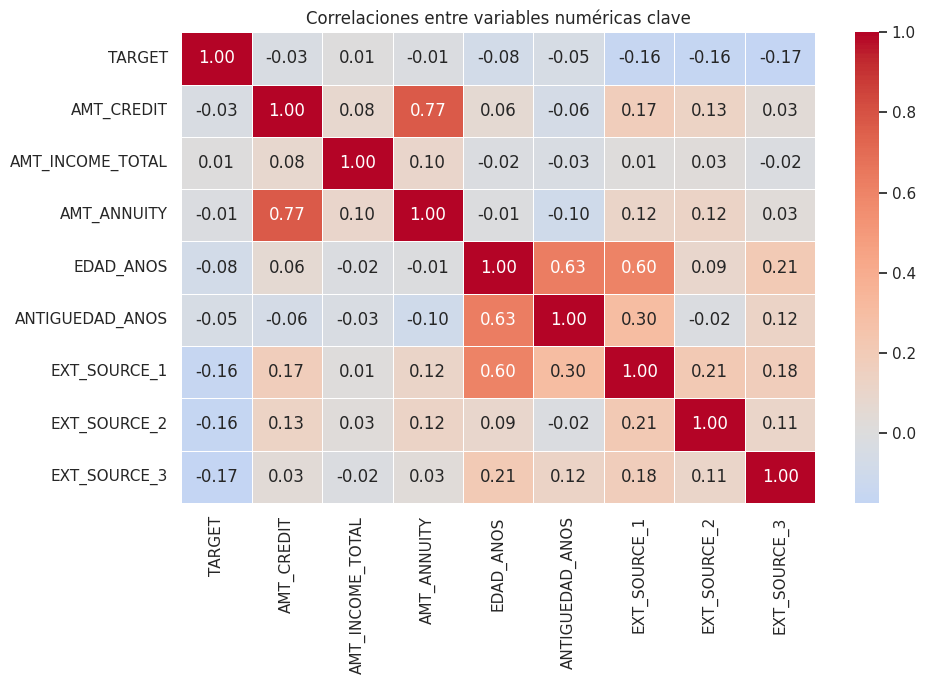

In [5]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Distribucion de pagadores y morosos
plt.subplot(1, 2, 1)
sns.countplot(data=datos_limpios, x='TARGET', palette='pastel')
plt.title('Distribucion de buenos pagadores (0) vs Morosos (1)')
plt.ylabel('Cantidad de Clientes')

# Relacion entre la edad y el monto del credito
plt.subplot(1, 2, 2)
sns.scatterplot(data=datos_limpios, x='EDAD_ANOS', y='AMT_CREDIT', hue='TARGET', alpha=0.3)
plt.title('Edad vs Monto del credito solicitado')
plt.xlabel('Edad (Años)')
plt.ylabel('Monto del Crédito')

plt.tight_layout()
plt.show()

# Tasa de mora por tipo de ingreso
# se calcula el porcentaje de morosos dentro de cada categoria de ingreso
tasa_mora_ingreso = datos_limpios.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
tasa_mora_ingreso.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Tasa de mora por tipo de ingreso del cliente')
plt.xlabel('Tipo de Ingreso')
plt.ylabel('Proporcion de Morosos')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Distribucion de ingresos por grupo (moroso vs pagador)
# se usa log para comprimir la escala ya que AMT_INCOME_TOTAL tiene sesgo alto (ver el analisis descriptivo)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=datos_limpios, x='AMT_INCOME_TOTAL', hue='TARGET', log_scale=True, fill=True, alpha=0.4, palette='pastel')
plt.title('Distribución de Ingresos: Morosos vs Buenos Pagadores (escala log)')
plt.xlabel('Ingreso Anual (escala logarítmica)')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()

# Mapa de calor de correlaciones entre variables numericas clave
# solo selecciono las columnas numericas mas relevantes para que el heatmap no quede casi que ilegible
columnas_heatmap = ['TARGET', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
                    'EDAD_ANOS', 'ANTIGUEDAD_ANOS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
correlaciones = datos_limpios[columnas_heatmap].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlaciones entre variables numéricas clave')
plt.tight_layout()
plt.show()

## >>> Modelado Fase 1: Clasificacion. ¿Es riesgoso un cliente o no?

In [6]:
# eval_metric='auc' le dice al modelo que su objetivo interno es maximizar el Área Bajo la Curva
modelo_clasificacion = XGBClassifier(random_state=42, eval_metric='auc')

parametros_xgboost = {
    'n_estimators': [100, 200, 300],    # Cuantos arboles
    'learning_rate': [0.01, 0.05, 0.1], # que tan rápido debe aprender
    'max_depth': [3, 5, 7],             # profundidad de los arboles
    'subsample': [0.8, 1.0]             # porcentaje de datos que usa cada árbol (para evitar memorizar)
}

# RandomizedSearchCV para ir rápido
# como se ve en el EDA los datos están fuertemente desbalanceados(casi 70,000 pagan bien vs 6,000 morosos)
# no puedo usar  accuracy porque el modelo aprobaria a casi todo el mudno
# se usa roc_auc para obtener una evaluacion mas honesta y robusta del poder de discriminacion del modelo
busqueda_modelo = RandomizedSearchCV(
    estimator=modelo_clasificacion,
    param_distributions=parametros_xgboost,
    n_iter=10,         # 10 combinaciones aleatorias para que cargue rapido :c
    scoring='roc_auc',
    cv=3,              
    random_state=42,
    n_jobs=-1         
)

print("Entrenando el modelo clasificador... espera unos minutos :)")
busqueda_modelo.fit(X_entreno, y_entreno)

# Extraccion del modelo ganador
mejor_xgboost_clase = busqueda_modelo.best_estimator_

#Evaluación del modelo con los datos de prueba
# predict_proba da la probabilidad (0 a 1) de ser moroso
predicciones_probabilidad = mejor_xgboost_clase.predict_proba(X_prueba)[:, 1]
roc_auc_final = roc_auc_score(y_prueba, predicciones_probabilidad)

print("\nEntrenamiento completado")
print(f"Metrica ROC-AUC final: {roc_auc_final:.4f} (Mientras más cerca de 1.0, mejor)")
print(f"Mejores hiperparametros elegidos por la máquina: {busqueda_modelo.best_params_}")

# Guardado del modelo
joblib.dump(mejor_xgboost_clase, '../models/mejor_modelo_clasificador.pkl')
print("Modelo guardado en '../models/mejor_modelo_clasificador.pkl'")

Entrenando el modelo clasificador... espera unos minutos :)

Entrenamiento completado
Metrica ROC-AUC final: 0.7447 (Mientras más cerca de 1.0, mejor)
Mejores hiperparametros elegidos por la máquina: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05}
Modelo guardado en '../models/mejor_modelo_clasificador.pkl'


Reporte de clasificación:
                  precision    recall  f1-score   support

Buen Pagador (0)       0.92      1.00      0.96     13793
      Moroso (1)       0.42      0.02      0.04      1207

        accuracy                           0.92     15000
       macro avg       0.67      0.51      0.50     15000
    weighted avg       0.88      0.92      0.88     15000



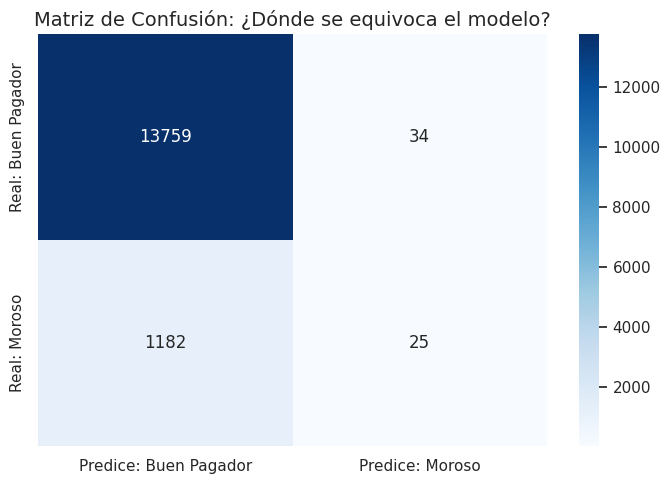

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

predicciones_clases = mejor_xgboost_clase.predict(X_prueba)

print("Reporte de clasificación:")
# para ver precision, recall y f1-score de una vez
print(classification_report(y_prueba, predicciones_clases, target_names=['Buen Pagador (0)', 'Moroso (1)']))

plt.figure(figsize=(7, 5))
matriz = confusion_matrix(y_prueba, predicciones_clases)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predice: Buen Pagador', 'Predice: Moroso'],
            yticklabels=['Real: Buen Pagador', 'Real: Moroso'])
plt.title('Matriz de Confusión: ¿Dónde se equivoca el modelo?', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Correccion del desbalanceo

# No estoy dispuesta a renunciar a esta base de datos, jaja
# Hya que calcular la proporción matematica del desbalanceo
# Cantidad de buenos pagadores / cantidad de morosos
peso_clases = (y_entreno == 0).sum() / (y_entreno == 1).sum()
print(f"Peso asignado a la clase moroso: {peso_clases:.2f}")

# Se extraen los mejores hiperparametros que encontro el RandomizedSearchCV en la celda anterior
# asi si se repite el experimento y cambian los resultados, no hay que actualizar nada a mano
mejores_params = busqueda_modelo.best_params_

# Entrenando un nuevo modelo usando los mejores hiperparámetros de antes usando scale_pos_weight
modelo_balanceado = XGBClassifier(
    **mejores_params,
    scale_pos_weight=peso_clases,
    random_state=42,
    eval_metric='auc'
)

print("Re-entrenando el modelo...")
modelo_balanceado.fit(X_entreno, y_entreno)

# Evaluacion del nuevo modelo
predicciones_balanceadas = modelo_balanceado.predict(X_prueba)

print("\nNuevo reporte de clasificación:")
print(classification_report(y_prueba, predicciones_balanceadas, target_names=['Buen Pagador (0)', 'Moroso (1)']))

joblib.dump(modelo_balanceado, '../models/mejor_modelo_clasificador.pkl')
print("\n Modelo balanceado guardado con éxito.")

Peso asignado a la clase moroso: 11.43
Re-entrenando el modelo...

Nuevo reporte de clasificación:
                  precision    recall  f1-score   support

Buen Pagador (0)       0.95      0.79      0.86     13793
      Moroso (1)       0.18      0.53      0.27      1207

        accuracy                           0.77     15000
       macro avg       0.57      0.66      0.57     15000
    weighted avg       0.89      0.77      0.82     15000


 Modelo balanceado guardado con éxito.


## >>> Modelado Fase 2: Regresion. ¿Cuanto dinero es seguro prestar?

### Este modelo solo se usara para los clientes que el primer modelo apruebe

In [9]:
# Filtro por clientes buenos (TARGET 0) para saber cuánto prestar
# el regresor se entrena en un subconjunto distinto al del clasificador (solo TARGET==0)
# esto no introduce data leakage porque el universo de clientes es diferente y AMT_CREDIT no fue usada como variable predictora en el modelo de clasificacion
datos_aprobados = datos_procesados[datos_procesados['TARGET'] == 0]

# AMT_CREDIT ahora es la 'y_reg' a predecir
X_reg = datos_aprobados.drop(['TARGET', 'AMT_CREDIT'], axis=1)
y_reg = datos_aprobados['AMT_CREDIT']

# entreno y prueba
X_entreno_reg, X_prueba_reg, y_entreno_reg, y_prueba_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Busqueda de hiperparametros para el regresor (misma logica que el clasificador)
parametros_regresor = {
    'n_estimators': [100, 200, 300],    # Cuantos arboles
    'learning_rate': [0.01, 0.05, 0.1], # que tan rápido debe aprender
    'max_depth': [3, 5, 7],             # poco profundo para evitar memorizar montos exactos
    'subsample': [0.8, 1.0]             # porcentaje de datos que usa cada árbol (para evitar memorizar)
}

busqueda_regresor = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=parametros_regresor,
    n_iter=10,         # 10 combinaciones aleatorias para que cargue rapido :c
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

print("Entrenando el modelo de regresion para calcular los montos de credito...")
busqueda_regresor.fit(X_entreno_reg, y_entreno_reg)

# Extraccion del modelo ganador
modelo_regresion = busqueda_regresor.best_estimator_

print(f"Mejores hiperparametros del regresor: {busqueda_regresor.best_params_}")

# predicciones y evaluacion
predicciones_montos = modelo_regresion.predict(X_prueba_reg)

# error de squared por version anterior del scikit learn
error_rmse = np.sqrt(mean_squared_error(y_prueba_reg, predicciones_montos))
r2 = r2_score(y_prueba_reg, predicciones_montos)

print("\nEntrenamiento del modelo de regresion completado")
print(f"Error cuadratico medio (RMSE): +/- $ {error_rmse:,.2f}")
print(f"Metrica R cuadrado (R2): {r2:.4f}")

joblib.dump(modelo_regresion, '../models/mejor_modelo_regresor.pkl')
print("Modelo de regresion en '../models/mejor_modelo_regresor.pkl'")

Entrenando el modelo de regresion para calcular los montos de credito...
Mejores hiperparametros del regresor: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}

Entrenamiento del modelo de regresion completado
Error cuadratico medio (RMSE): +/- $ 48,237.80
Metrica R cuadrado (R2): 0.9860
Modelo de regresion en '../models/mejor_modelo_regresor.pkl'
